In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LogisticRegression

In [44]:
df = pd.read_csv('customer_churn_clean.csv')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [45]:
print(f'The database is composed of {df.shape[0]} observations and {df.shape[1]} columns\n')
print(f'The given columns or features are:\n \n {df.columns.unique().values}\n')

The database is composed of 7043 observations and 21 columns

The given columns or features are:
 
 <StringArray>
[      'customerID',           'gender',    'SeniorCitizen',
          'Partner',       'Dependents',           'tenure',
     'PhoneService',    'MultipleLines',  'InternetService',
   'OnlineSecurity',     'OnlineBackup', 'DeviceProtection',
      'TechSupport',      'StreamingTV',  'StreamingMovies',
         'Contract', 'PaperlessBilling',    'PaymentMethod',
   'MonthlyCharges',     'TotalCharges',            'Churn']
Length: 21, dtype: str



In [46]:
binary = []
non_binary = []
continuous = []

for i in df.columns:
    #print(i)
    # print(df[str(i)].unique())
    if df[str(i)].nunique()==2:
        binary.append(i)
    elif df[str(i)].nunique()>2 and pd.api.types.is_numeric_dtype(df[str(i)]):
        continuous.append(i)
    else:
        non_binary.append(i)

summary = {'Binary': binary, 'Non-Binary': non_binary, 'Continuous': continuous}
summary

{'Binary': ['gender',
  'SeniorCitizen',
  'Partner',
  'Dependents',
  'PhoneService',
  'PaperlessBilling',
  'Churn'],
 'Non-Binary': ['customerID',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaymentMethod'],
 'Continuous': ['tenure', 'MonthlyCharges', 'TotalCharges']}

In [47]:
# Checking for missing data and data type

print(df.isna().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [48]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

       SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    7043.000000  7043.000000     7043.000000   7043.000000
mean        0.162147    32.371149       64.761692   2279.734304
std         0.368612    24.559481       30.090047   2266.794470
min         0.000000     0.000000       18.250000      0.000000
25%         0.000000     9.000000       35.500000    398.550000
50%         0.000000    29.000000       70.350000   1394.550000
75%         0.000000    55.000000       89.850000   3786.600000
max         1.000000    72.000000      118.750000   8684.800000


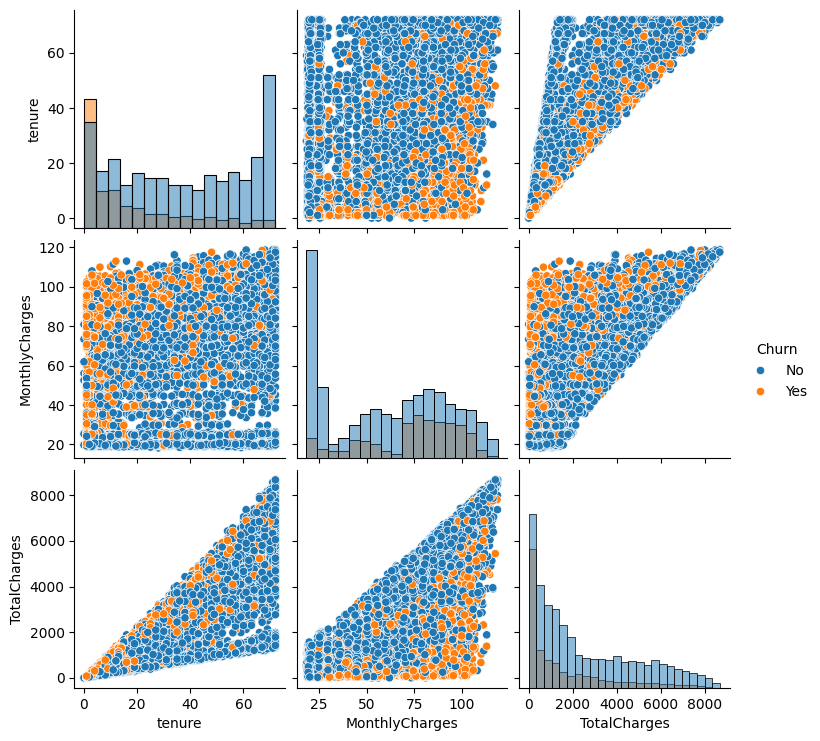

In [49]:
print(df.describe())
sns.pairplot(df[continuous+['Churn']], hue='Churn', diag_kind='hist')

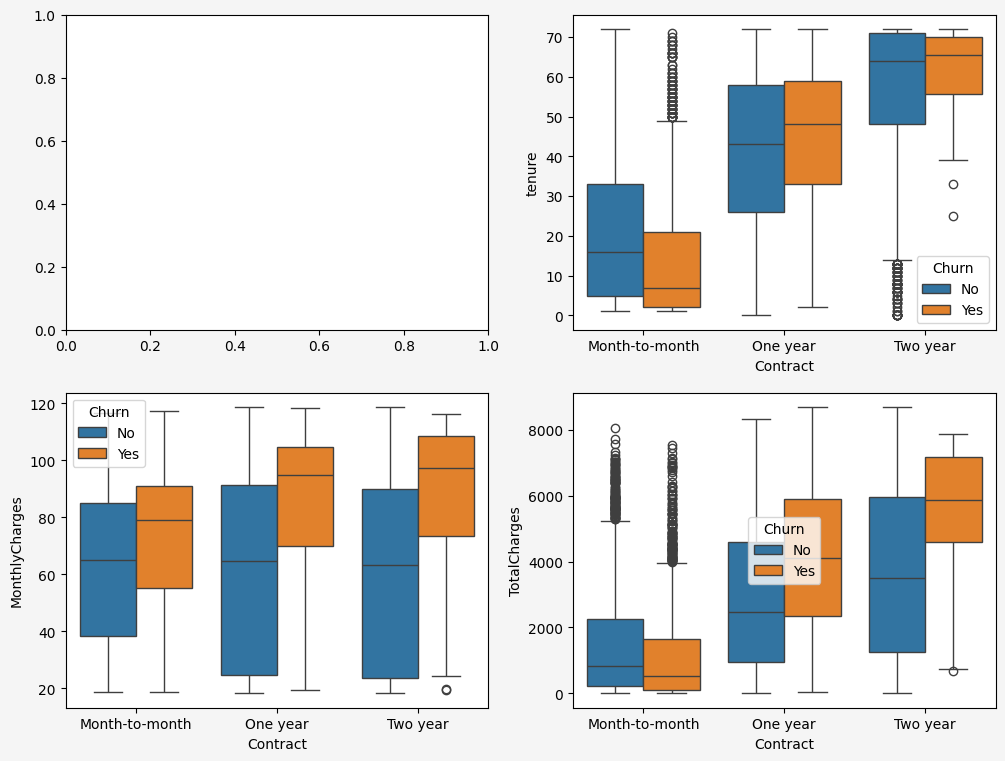

In [50]:
# Creating subplots for binary features

fig, ax = plt.subplots(2,2, figsize=(12,9))
fig.patch.set_facecolor('whitesmoke')

for i, feature in enumerate(continuous, start=1):
    sns.boxplot(df, x='Contract',y=feature, ax=ax[i//2][i%2], hue='Churn')



In [51]:
summary

{'Binary': ['gender',
  'SeniorCitizen',
  'Partner',
  'Dependents',
  'PhoneService',
  'PaperlessBilling',
  'Churn'],
 'Non-Binary': ['customerID',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaymentMethod'],
 'Continuous': ['tenure', 'MonthlyCharges', 'TotalCharges']}

In [117]:
df1 = df.copy()
df1 = df1.drop(columns=['customerID'])

In [118]:
# Let us make the binary features into dummy variables

df1 = pd.get_dummies(df1, columns=binary, dtype=int, drop_first=True)
df1

,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaymentMethod,MonthlyCharges,TotalCharges,gender_Male,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PhoneService_Yes,PaperlessBilling_Yes,Churn_Yes
0,1,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Electronic check,29.85,29.85,0,0,1,0,0,1,0
1,34,No,DSL,Yes,No,Yes,No,No,No,One year,Mailed check,56.95,1889.50,1,0,0,0,1,0,0
2,2,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Mailed check,53.85,108.15,1,0,0,0,1,1,1
3,45,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,Bank transfer (automatic),42.30,1840.75,1,0,0,0,0,0,0
4,2,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Electronic check,70.70,151.65,0,0,0,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,24,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Mailed check,84.80,1990.50,1,0,1,1,1,1,0
7039,72,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Credit card (automatic),103.20,7362.90,0,0,1,1,1,1,0
7040,11,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Electronic check,29.60,346.45,0,0,1,1,0,1,0
7041,4,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Mailed check,74.40,306.60,1,1,1,0,1,1,1


In [111]:
df1['MultipleLines_Yes'].unique()

array([0, 1])

In [60]:
#df=df.drop(['customerID'], axis=1)

#X,y = df.drop('Churn', axis=1).copy(), df['Churn'].copy()

X,y = df[continuous], df['Churn'].copy()

print(X.shape, y.shape)

model = LogisticRegression()

model.fit(X,y)

print(model.score(X,y))

# y_pred = model.predict(X)

y_pred_proba = model.predict_proba(X)

print(y_pred_proba)

# print(y_pred)


(7043, 3) (7043,)
0.7846088314638648
[[0.68466606 0.31533394]
 [0.86815603 0.13184397]
 [0.52547739 0.47452261]
 ...
 [0.8026037  0.1973963 ]
 [0.39728105 0.60271895]
 [0.86336123 0.13663877]]


In [55]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

**Using `enumerate` in Python**

`enumerate(iterable, start=0)` yields pairs of `(index, value)` while iterating. Use it when you need the loop index and the item.

Common patterns:
- `for i, v in enumerate(items):` — zero-based index
- `for i, v in enumerate(items, start=1):` — one-based index

See the code example in the next cell.

In [ ]:
# Encoding examples using np.where
# 1) Binary encode `Churn` (handles common string forms)
df['Churn_encoded'] = np.where(df['Churn'].astype(str).str.lower().isin(['yes','true','1']), 1, 0)

# 2) Numeric threshold encoding (High/Low monthly charges)
df['HighMonthlyCharges'] = np.where(df['MonthlyCharges'] > df['MonthlyCharges'].median(), 'High', 'Low')

# 3) Chained np.where for multi-case encoding (PaymentMethod -> codes)
df['Payment_encoded'] = np.where(df['PaymentMethod'] == 'Electronic check', 0,
                          np.where(df['PaymentMethod'] == 'Mailed check', 1, 2))

# Preview the new columns
df[['Churn', 'Churn_encoded', 'MonthlyCharges', 'HighMonthlyCharges', 'PaymentMethod', 'Payment_encoded']].head()